In [1]:
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

In [3]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [4]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df.shape

(150, 4)

In [6]:
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
#setosa, versicolor, virginica represent 0,1,2 respectively

In [10]:
df[df.target==1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [11]:
df[df.target==2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [12]:
df.shape

(150, 5)

In [13]:
# from the analysis above, it is clear that we have 150 rows:
# the first 50 are 0, the second 50 are 1 and the last 50 i.e. 100to150 are 2

In [14]:
#let's do some separation

In [16]:
df0 = df[:50]
df1 = df[50:100]
df2 = df[100:]

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

### Plot of sepal length versus width

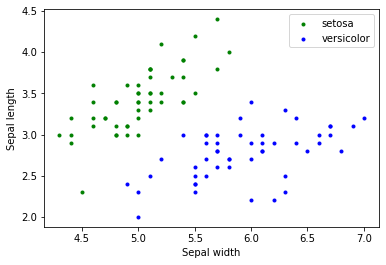

In [18]:
plt.xlabel('Sepal width')
plt.ylabel('Sepal length')
plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], color='green', marker='.', label='setosa')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color='blue', marker='.', label='versicolor')
plt.legend()

### Plot of petal length versus width

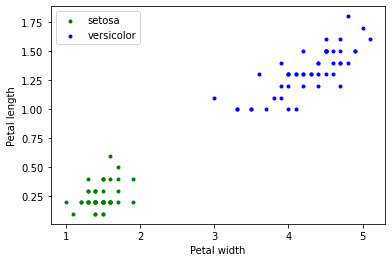

In [19]:
plt.xlabel('Petal width')
plt.ylabel('Petal length')
plt.scatter(df0['petal length (cm)'], df0['petal width (cm)'], color='green', marker='.', label='setosa')
plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'], color='blue', marker='.', label='versicolor')
plt.legend()

In [20]:
from sklearn.model_selection import train_test_split

In [28]:
X = df.drop('target', axis=1)
y = df.target

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [33]:
from sklearn.neighbors import KNeighborsClassifier

In [35]:
knn = KNeighborsClassifier(n_neighbors=3)

In [36]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [37]:
knn.score(X_test, y_test)

1.0

In [38]:
from sklearn.metrics import confusion_matrix

In [42]:
y_pred = knn.predict(X_test)
y_actual = y_test

cm = confusion_matrix(y_actual, y_pred)
cm

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]], dtype=int64)

Text(51.0, 0.5, 'Actual')

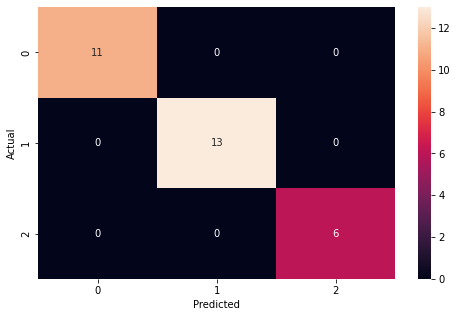

In [44]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [45]:
#let's get the classification report
from sklearn.metrics import classification_report 

In [47]:
cr = classification_report(y_actual, y_pred)
cr

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        11\n           1       1.00      1.00      1.00        13\n           2       1.00      1.00      1.00         6\n\n    accuracy                           1.00        30\n   macro avg       1.00      1.00      1.00        30\nweighted avg       1.00      1.00      1.00        30\n'

In [48]:
##let's print it to have a better view
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

